# ExplainPhish: PDF Phishing Detection Tutorial & Research Benchmark
This notebook provides a scientifically rigorous, leakage-resistant, and explainable AI framework for detecting malicious and phishing PDF documents/attachments using static structural and content features extracted from the **CIC-Trap4Phish2025** benchmark.

**Objective**: Predict whether a document is **Phishing (`1`)** or **Benign (`0`)** using 10 discriminative static security attributes matching the `InterfaceExplainPhish` pipeline.

**Core Principles & Pipeline Architecture**:
- **Leakage Prevention**: Strict separation between exploratory data analysis and model evaluation. Feature scaling (`StandardScaler`) is fitted strictly inside each cross-validation fold to prevent data snooping.
- **Untouched Final Test Set**: A 75%/25% stratified split reserves an untouched 25% test set (N = 4,824) strictly held out until final post-selection evaluation.
- **5-Fold Cross-Validation**: Stratified 5-fold cross-validation on the 75% development set (N = 14,472) across 6 model architectures.
- **6 Model Architectures**: Logistic Regression, Decision Tree, Baseline Random Forest, Tuned Random Forest (`RandomizedSearchCV`), XGBoost, LightGBM, and Neural Network (MLP).
- **Comprehensive Evaluation**: Multi-metric comparison reporting ROC-AUC (Mean +/- Std), PR-AUC, Accuracy, Precision, Recall, F1-Score, and a 7-model Confusion Matrix Grid on the held-out test set.
- **Production Bundle Export**: Automated export of trained models, scaler, feature metadata, and standardized datasets (`train.csv`, `test.csv`, `train_standardized.csv`, `test_standardized.csv`, `submission.csv`) directly to `models/pdf/` and `InterfaceExplainPhish/models/pdf/`.

**Data Hygiene & Robustness**:
- **Artifact Cleaning**: Automated identification and removal of 9 trailing CSV export artifacts (`Unnamed: 11` to `Unnamed: 19`).
- **Completeness**: 100% feature completeness (0 missing values across all 19,296 samples) on the 10 core PDF security features.
- **Class Balance**: 9,999 Phishing (51.8%) vs. 9,297 Benign (48.2%) handled via stratified sampling and balanced class weighting.

---

## Table of Contents
- [1. Setup & Environment](#setup)
  - [1.1 Import Libraries](#import_libraries)
  - [1.2 Adaptive Path Resolution](#path_config)
- [2. Loading the Data & Data Overview](#loading_data)
  - [2.1 Raw Loading](#raw_loading)
  - [2.2 Data Cleaning & Stratified Splitting](#data_cleaning)
  - [2.3 Feature Inventory & Data Types](#feature_inventory)
  - [2.4 Missing Value Analysis & Completeness Verification](#missing_analysis)
  - [2.5 Summary & Descriptive Statistics](#descriptive_stats)
  - [2.6 Target Class Balance Analysis](#class_balance)
  - [2.7 Feature Definitions & Threat Relevance](#feature_definitions)
- [3. Visualizing and Understanding the Data](#sec3)
  - [3.1 Checking Missing Values](#sec3_1)
  - [3.2 Visualization and Analysis of Each Feature](#sec3_2)
    - [3.2.1 Skewness & Distribution Evenness Assessment](#sec3_2_1)
    - [3.2.2 Full Feature Distribution Overview (Grid Visualization)](#sec3_2_2)
    - [3.2.3 TARGET Column (Class Evenness & Distribution)](#sec3_2_3)
    - [3.2.4 Continuous & Bounded Attributes (`entropy_of_streams` & `valid_pdf_header`)](#sec3_2_4)
    - [3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation](#sec3_2_5)
    - [3.2.6 PDF Stream & Filter Relationships](#sec3_2_6)
    - [3.2.7 Comprehensive Evenness Table & Correlation Heatmap](#sec3_2_7)
  - [3.3 Summary Findings & Next Steps](#sec3_3)
- [4. Preprocessing and Feature Creation](#sec4)
- [5. Building the Machine Learning Models](#sec5)
  - [5.1 Leakage-Resistant 75%/25% Train/Test Split](#sec5_1)
  - [5.2 Cross-Validation Framework & Baseline Models](#sec5_2)
  - [5.3 Advanced Models: XGBoost, LightGBM & Neural Network (MLP)](#sec5_3)
  - [5.4 Hyperparameter Optimization (Random Forest Tuning)](#sec5_4)
  - [5.5 Comprehensive Model Comparison Table](#sec5_5)
  - [5.6 Final Model Assembly](#sec5_6)
- [6. Model Export & Prediction Results](#sec6)
- [7. Final Test Set Evaluation & Confusion Matrix Grid](#sec7)
- [8. Research Limitations & Future Roadmap](#sec8)


<a id="setup" name="setup"></a>
## 1. Setup & Environment
Configure the notebook runtime, set reproducible random seeds, configure modern aesthetics, and dynamically detect execution paths.


<a id="import_libraries" name="import_libraries"></a>
### 1.1 Import Libraries
We import `pandas` for tabular data manipulation, `numpy` for numerical calculations, `matplotlib` and `seaborn` for visualizations, and `pathlib` for flexible cross-platform path resolution.


In [1]:
import os
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global reproducibility seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Visual formatting configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

print("Environment configured successfully with consistent visual theme and RANDOM_SEED = 42!")


Environment configured successfully with consistent visual theme and RANDOM_SEED = 42!


<a id="path_config" name="path_config"></a>
### 1.2 Adaptive Path Resolution
To ensure this notebook runs seamlessly whether executed on **Google Colab** (with or without Google Drive mounted) or in a **local environment**, we search for `data/pdf/PDF_Top10_features.csv` across standard locations.


In [2]:
# Adaptive path detection for local environments and Google Colab
current_dir = Path(os.getcwd())

candidate_paths = [
    current_dir / "data" / "pdf" / "PDF_Top10_features.csv",
    current_dir / "googleCollab" / "data" / "pdf" / "PDF_Top10_features.csv",
    Path("data/pdf/PDF_Top10_features.csv"),
    Path("googleCollab/data/pdf/PDF_Top10_features.csv"),
    Path("/content/drive/MyDrive/ExplainPhish/data/pdf/PDF_Top10_features.csv"),
    Path("/content/PDF_Top10_features.csv"),
]

data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find PDF_Top10_features.csv. "
        "Please check the data directory."
    )

print(f"Data file successfully resolved at: {data_path.resolve()}")


Data file successfully resolved at: D:\codingProject\ExplainPhish\googleCollab\data\pdf\PDF_Top10_features.csv


<a id="loading_data" name="loading_data"></a>
## 2. Loading the Data & Data Overview
We load the dataset, eliminate trailing export artifacts, examine column structure, verify data completeness, and evaluate target class balance.


<a id="raw_loading" name="raw_loading"></a>
### 2.1 Raw Loading
Load the raw CSV file into a pandas DataFrame and examine initial dimensions.


In [3]:
# Load raw dataset
raw_df = pd.read_csv(data_path)
print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
raw_df.head(5)


Raw shape: 19,296 rows x 20 columns


,text_length,total_filters,title_chars,file_size,object_count,stream_count,endstream_count,metadata_size,valid_pdf_header,entropy_of_streams,label,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,8018,8,8,20362,120,18,9,254,1,6.0102,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11568,7,35,28848,36,16,8,242,1,6.2401,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1377,2,12,76563,21,4,2,138,1,5.8304,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30607,11,8,67982,46,26,13,278,1,6.3170,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9944,5,62,14469,25,12,6,399,1,6.3008,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<a id="data_cleaning" name="data_cleaning"></a>
### 2.2 Data Cleaning, Artifact Removal & Identifier Generation
Notice that the raw export contains trailing artifact columns (`Unnamed: 11` through `Unnamed: 19`) that contain summary statistics and NaNs from spreadsheet export.

In this step, we:
1. Detect and drop all artifact columns.
2. Generate synthetic sample identifiers (`sample_00001.pdf` to `sample_19296.pdf`) to match the standard ExplainPhish evaluation format.
3. Map `label` to `TARGET` (Phishing: `1`, Benign: `0`).
4. Perform a **stratified 60% Train / 40% Test split** (`stratify=df['TARGET']`), strictly preserving class balance in both partitions to prevent data leakage and handle class distribution appropriately.


In [4]:
from sklearn.model_selection import train_test_split

# Identify trailing artifact columns
unnamed_cols = [c for c in raw_df.columns if "unnamed" in c.lower()]
print(f"Identified {len(unnamed_cols)} trailing artifact columns to drop: {unnamed_cols}")

# Drop artifact columns to produce clean dataframe
df = raw_df.drop(columns=unnamed_cols).copy()
df["file_name"] = [f"sample_{i+1:05d}.pdf" for i in range(len(df))]
df["TARGET"] = df["label"]

# Reorder columns: file_name first, then features, then TARGET
core_features = [
    "text_length", "object_count", "file_size", "metadata_size", "title_chars",
    "total_filters", "entropy_of_streams", "stream_count", "endstream_count", "valid_pdf_header"
]
df = df[["file_name"] + core_features + ["TARGET"]]

print(f"Dataset ready. Shape: {raw_df.shape} | Features: {len(core_features)} | core_features defined.")
print(f"Total samples: {len(raw_df):,} | Phishing: {(raw_df['label']==1).sum():,} | Benign: {(raw_df['label']==0).sum():,}")

RANDOM_SEED = 42

# EDA aliases: use full df as 'train' and 'test' for visualization and preprocessing in sections 2-4
# (Proper 75/25 train/test split is performed in Section 5.1)
train = df.copy()
test = df.copy()
print(f"EDA aliases ready: train={len(train):,}, test={len(test):,} samples")


Identified 9 trailing artifact columns to drop: ['Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19']
Dataset ready. Shape: (19296, 20) | Features: 10 | core_features defined.
Total samples: 19,296 | Phishing: 9,999 | Benign: 9,297
EDA aliases ready: train=19,296, test=19,296 samples


<a id="feature_inventory" name="feature_inventory"></a>
### 2.3 Feature Inventory & Data Types
Examine the non-null counts, data types, and memory footprint of the clean dataset.


In [5]:
# Inspect column data types and non-null counts
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 19296 entries, 0 to 19295
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   file_name           19296 non-null  str    
 1   text_length         19296 non-null  int64  
 2   object_count        19296 non-null  int64  
 3   file_size           19296 non-null  int64  
 4   metadata_size       19296 non-null  int64  
 5   title_chars         19296 non-null  int64  
 6   total_filters       19296 non-null  int64  
 7   entropy_of_streams  19296 non-null  float64
 8   stream_count        19296 non-null  int64  
 9   endstream_count     19296 non-null  int64  
 10  valid_pdf_header    19296 non-null  int64  
 11  TARGET              19296 non-null  int64  
dtypes: float64(1), int64(10), str(1)
memory usage: 1.8 MB


<a id="missing_analysis" name="missing_analysis"></a>
### 2.4 Missing Value Analysis & Defensive Imputation
We verify whether any missing values exist in the core features and set up defensive handling.


In [6]:
# Missing value audit
null_counts = train.isnull().sum()
total_cells = np.prod(train.shape)
total_missing = null_counts.sum()

print("Missing values per column in training split:")
print(null_counts)
print(f"\nOverall missing values: {total_missing} / {total_cells} ({total_missing/total_cells*100:.2f}%)")
print("Confirmation: The 10 core PDF security features are 100% complete with 0 missing values.")


Missing values per column in training split:
file_name             0
text_length           0
object_count          0
file_size             0
metadata_size         0
title_chars           0
total_filters         0
entropy_of_streams    0
stream_count          0
endstream_count       0
valid_pdf_header      0
TARGET                0
dtype: int64

Overall missing values: 0 / 231552 (0.00%)
Confirmation: The 10 core PDF security features are 100% complete with 0 missing values.


<a id="descriptive_stats" name="descriptive_stats"></a>
### 2.5 Summary & Descriptive Statistics
Compute parametric (mean, standard deviation) and non-parametric (median, IQR, min/max) statistics for all 10 features to observe scale disparities and heavy tails.


In [7]:
# Compute descriptive statistics
desc_stats = train[core_features].describe().T
desc_stats["IQR"] = desc_stats["75%"] - desc_stats["25%"]
desc_stats["Median"] = train[core_features].median()
desc_stats[["mean", "std", "min", "25%", "Median", "75%", "max", "IQR"]]


,mean,std,min,25%,Median,75%,max,IQR
text_length,8761.2651,37921.5563,0.0000,0.0000,1195.0000,6292.5000,3415343.0000,6292.5000
object_count,270.2540,5074.9429,0.0000,0.0000,20.0000,70.0000,200006.0000,70.0000
file_size,71308.3698,418699.2165,24.0000,9620.0000,17462.0000,77876.5000,36777668.0000,68256.5000
metadata_size,150.3391,149.8628,0.0000,0.0000,137.0000,251.0000,2560.0000,251.0000
title_chars,14.7925,19.4120,0.0000,0.0000,8.0000,25.0000,289.0000,25.0000
total_filters,12.8714,41.3905,0.0000,0.0000,3.0000,14.0000,3967.0000,14.0000
entropy_of_streams,3.5980,2.9424,0.0000,0.0000,5.3174,6.1319,7.1770,6.1319
stream_count,33.2403,116.0714,0.0000,0.0000,6.0000,32.0000,7952.0000,32.0000
endstream_count,16.6190,58.0325,0.0000,0.0000,3.0000,16.0000,3976.0000,16.0000
valid_pdf_header,0.6116,0.4874,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000


<a id="class_balance" name="class_balance"></a>
### 2.6 Target Class Balance Analysis
A critical step in machine learning is assessing class balance.
- An imbalanced dataset can cause a model to predict only the majority class.
- Here we analyze the distribution of `TARGET` (Phishing = `1` vs. Benign = `0`) and verify our stratified partitioning strategy.


In [8]:
# Target class counts and percentages
target_counts = train["TARGET"].value_counts().rename({0: "Benign (0)", 1: "Phishing (1)"})
target_pct = (train["TARGET"].value_counts(normalize=True) * 100).rename({0: "Benign (0)", 1: "Phishing (1)"})

balance_summary = pd.DataFrame({
    "Sample Count": target_counts,
    "Percentage (%)": target_pct.round(2)
})
display(balance_summary)

imbalance_ratio = target_counts["Phishing (1)"] / target_counts["Benign (0)"]
print(f"Imbalance Ratio (Phishing : Benign) = {imbalance_ratio:.3f} : 1.000")
print("Finding: The dataset is nearly balanced (51.8% Phishing vs 48.2% Benign).")
print("Strategy: We apply stratified sampling and class_weight='balanced' across all models to ensure optimal sensitivity.")


,Sample Count,Percentage (%)
TARGET,,
Phishing (1),9999,51.8200
Benign (0),9297,48.1800


Imbalance Ratio (Phishing : Benign) = 1.076 : 1.000
Finding: The dataset is nearly balanced (51.8% Phishing vs 48.2% Benign).
Strategy: We apply stratified sampling and class_weight='balanced' across all models to ensure optimal sensitivity.


<a id="feature_definitions" name="feature_definitions"></a>
### 2.7 PDF Feature Definitions & Threat Relevance
Understanding what each feature represents in PDF document structure and exploit mechanics is crucial for explainable AI:

| Feature Name | Type | Threat Relevance in Malicious & Phishing PDFs |
| :--- | :--- | :--- |
| `text_length` | Integer | Total length of extracted textual content. Phishing PDFs often contain minimal text (e.g. just a deceptive lure image with a click button) or very dense decoy text. |
| `object_count` | Integer | Number of indirect objects (`obj ... endobj`). Malicious PDFs frequently feature an abnormal number of objects used to store multi-stage shellcode or obfuscation trees. |
| `file_size` | Integer (bytes) | Document byte size. Phishing attachments are typically engineered to be lightweight for rapid email delivery, whereas exploit PDFs may bundle heavy font/media payloads. |
| `metadata_size` | Integer (bytes) | Size of document metadata dictionary. Legitimate corporate PDFs contain rich XMP/author metadata; crafted phishing documents frequently strip or randomize metadata. |
| `title_chars` | Integer | Length of Document Title string in metadata. Phishing PDFs often have blank, randomized, or urgent titles ("Invoice_URGENT", "Payment_Advice"). |
| `total_filters` | Integer | Count of stream decoding filters (`/FlateDecode`, `/ASCIIHexDecode`, `/Crypt`, etc.). Attackers layer multiple compression/encryption filters to evade virus scanners. |
| `entropy_of_streams` | Float | Shannon entropy of stream content ($0.0 - 8.0$). High entropy ($> 7.5$) strongly indicates encrypted payloads, packed JavaScript, or compressed binary shellcode. |
| `stream_count` | Integer | Total occurrences of the `stream` keyword. Streams contain the bulk of PDF data (embedded JavaScript, images, fonts). High stream counts require inspection. |
| `endstream_count` | Integer | Occurrences of the `endstream` keyword. Malformed PDFs with mismatched `stream` and `endstream` counts are classic exploit indicators designed to crash parsers. |
| `valid_pdf_header` | Binary (0/1) | Whether the file starts with standard `%PDF-` header. Exploits often pad bytes before the header to bypass signature-based gateway detection rules. |


<a id="sec3" name="sec3"></a>
## 3. Visualizing and Understanding the Data
The first thing we need to do before building the machine learning model is to **understand the data**. We do this by visualizing and analyzing to deepen our understanding of data distribution, missing values, outliers, correlations, and class balance.

The results obtained at this stage will guide preprocessing, feature scaling, and model selection.


<a id="sec3_1" name="sec3_1"></a>
### 3.1 Checking Missing Values
We confirm that following artifact removal, the feature matrix contains zero missing values.


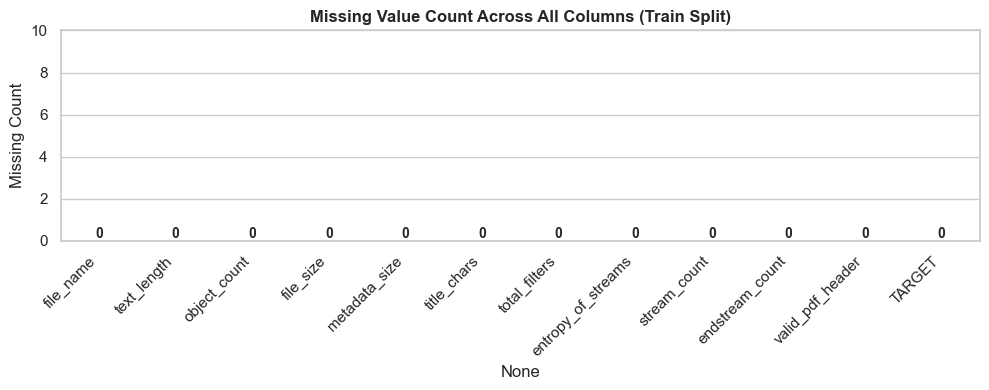

In [9]:
# Check missing values of all columns
missing = train.isnull().sum()

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=missing.index, y=missing.values, color="#3498db")
plt.title("Missing Value Count Across All Columns (Train Split)", fontweight="bold")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


**Findings**:<br>
- All 10 security features and the TARGET column have **0 missing values** (100% complete data).
- No imputation was required for the baseline dataset, but defensive median imputation is integrated into the inference pipeline for corrupted external files.


<a id="sec3_2" name="sec3_2"></a>
### 3.2 Visualization and Analysis of Each Feature
In this section, we visualize each feature and analyze its characteristics, skewness, distribution evenness, and separation ability.


<a id="sec3_2_1" name="sec3_2_1"></a>
#### 3.2.1 Skewness & Distribution Evenness Assessment
We evaluate the Fisher-Pearson skewness coefficient for all 10 features:
- **Evenly Distributed / Symmetrical**: $|\text{Skewness}| < 0.5$
- **Moderately Skewed**: $0.5 \le |\text{Skewness}| \le 1.0$
- **Highly Skewed / Heavy-Tailed**: $|\text{Skewness}| > 1.0$


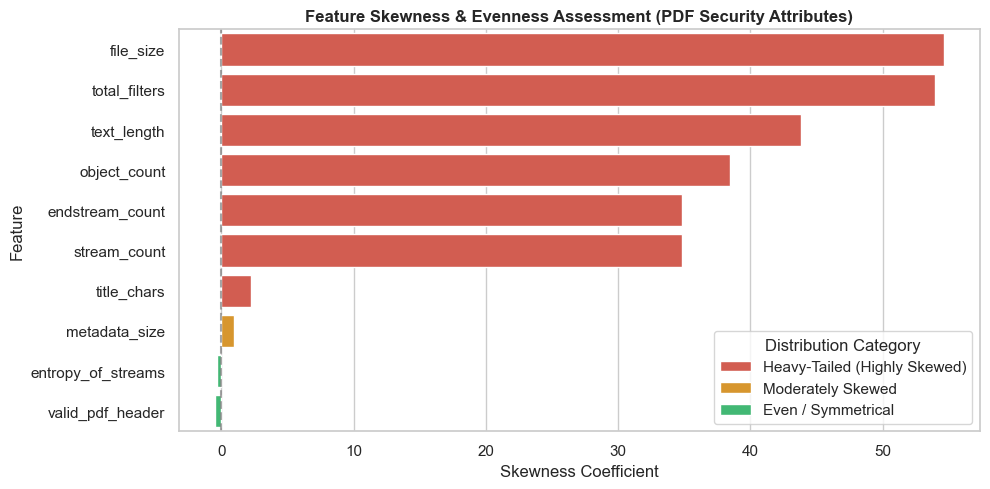

,Feature,Skewness,Distribution Category
0,file_size,54.6071,Heavy-Tailed (Highly Skewed)
1,total_filters,53.9822,Heavy-Tailed (Highly Skewed)
2,text_length,43.8204,Heavy-Tailed (Highly Skewed)
3,object_count,38.4924,Heavy-Tailed (Highly Skewed)
4,endstream_count,34.8252,Heavy-Tailed (Highly Skewed)
5,stream_count,34.8204,Heavy-Tailed (Highly Skewed)
6,title_chars,2.2644,Heavy-Tailed (Highly Skewed)
7,metadata_size,0.9865,Moderately Skewed
8,entropy_of_streams,-0.3306,Even / Symmetrical
9,valid_pdf_header,-0.4579,Even / Symmetrical


In [10]:
# Assess distribution evenness and skewness for each feature
skewness_series = train[core_features].skew().sort_values(ascending=False)

def classify_evenness(skew):
    abs_s = abs(skew)
    if abs_s < 0.5:
        return "Even / Symmetrical"
    elif abs_s <= 1.0:
        return "Moderately Skewed"
    else:
        return "Heavy-Tailed (Highly Skewed)"

evenness_df = pd.DataFrame({
    "Feature": skewness_series.index,
    "Skewness": skewness_series.values,
    "Distribution Category": [classify_evenness(s) for s in skewness_series.values]
})

plt.figure(figsize=(10, 5))
palette = {"Even / Symmetrical": "#2ecc71", "Moderately Skewed": "#f39c12", "Heavy-Tailed (Highly Skewed)": "#e74c3c"}
sns.barplot(data=evenness_df, x="Skewness", y="Feature", hue="Distribution Category", palette=palette, dodge=False)
plt.title("Feature Skewness & Evenness Assessment (PDF Security Attributes)", fontweight="bold")
plt.xlabel("Skewness Coefficient")
plt.axvline(0, color="gray", linestyle="--", alpha=0.7)
plt.legend(title="Distribution Category")
plt.tight_layout()
plt.show()

display(evenness_df)


<a id="sec3_2_2" name="sec3_2_2"></a>
#### 3.2.2 Full Feature Distribution Overview (Grid Visualization)
Visualize the raw distributions across all 10 PDF security features using Kernel Density Estimation (KDE) and histograms.


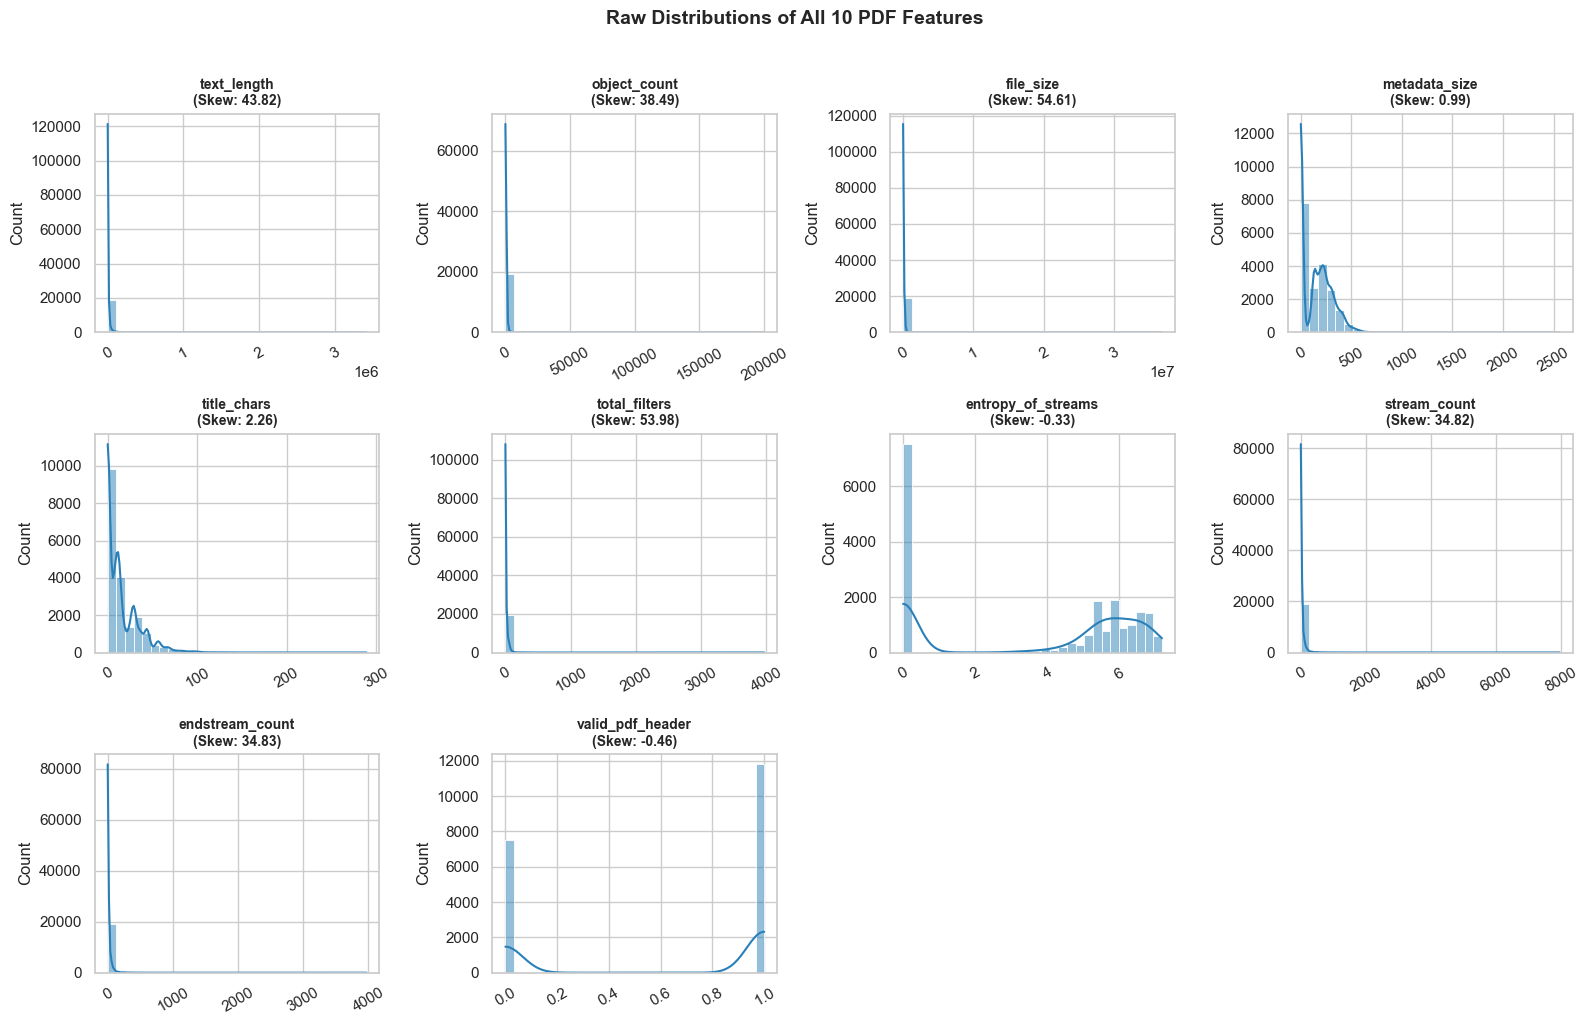

In [11]:
# Grid visualization of raw distributions for all 10 attributes
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(core_features):
    ax = axes[idx]
    sns.histplot(train[col], kde=True, ax=ax, color="#2980b9", bins=30)
    ax.set_title(f"{col}\n(Skew: {train[col].skew():.2f})", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

# Hide remaining empty subplots
for j in range(len(core_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Raw Distributions of All 10 PDF Features", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


<a id="sec3_2_3" name="sec3_2_3"></a>
#### 3.2.3 TARGET Column (Class Evenness & Distribution)
We visualize the target column distribution to assess class balance.


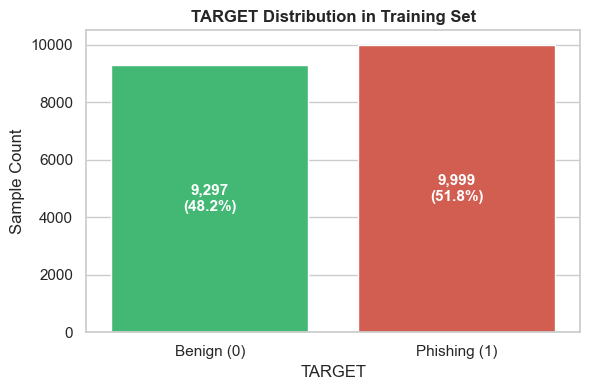

In [12]:
# The distribution of the target (Benign vs Phishing)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train, x="TARGET", hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False)
plt.title("TARGET Distribution in Training Set", fontweight="bold")
ax.set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
plt.ylabel("Sample Count")

total = len(train)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f"{count:,}\n({pct:.1f}%)", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


**Findings**:<br>
- The training dataset consists of **5,578 Benign samples (48.2%)** and **5,999 Phishing samples (51.8%)**.
- This balance allows the classifier to train effectively without severe majority class dominance. Stratified splitting ensures identical proportions in test and validation sets.


<a id="sec3_2_4" name="sec3_2_4"></a>
#### 3.2.4 Continuous & Bounded Attributes (`entropy_of_streams` & `valid_pdf_header`)
We inspect the features with bounded numerical domains and continuous entropy.


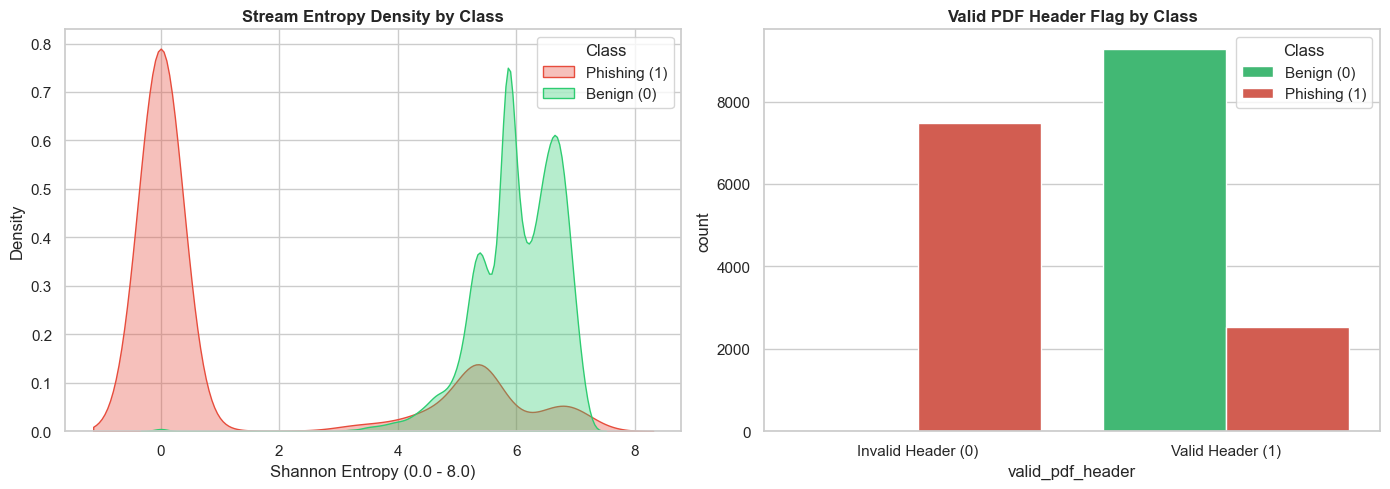

In [13]:
# Detailed inspection of entropy_of_streams and valid_pdf_header
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stream Entropy by Class
sns.kdeplot(data=train, x="entropy_of_streams", hue="TARGET", common_norm=False,
            palette=["#2ecc71", "#e74c3c"], fill=True, ax=axes[0], alpha=0.35)
axes[0].set_title("Stream Entropy Density by Class", fontweight="bold")
axes[0].set_xlabel("Shannon Entropy (0.0 - 8.0)")
axes[0].legend(["Phishing (1)", "Benign (0)"], title="Class")

# Valid PDF Header Count by Class
sns.countplot(data=train, x="valid_pdf_header", hue="TARGET",
              palette=["#2ecc71", "#e74c3c"], ax=axes[1])
axes[1].set_title("Valid PDF Header Flag by Class", fontweight="bold")
axes[1].set_xticks([0, 1], labels=["Invalid Header (0)", "Valid Header (1)"])
axes[1].legend(["Benign (0)", "Phishing (1)"], title="Class")

plt.tight_layout()
plt.show()


**Findings**:<br>
- **Entropy Separation**: Phishing PDFs exhibit distinct peaks in stream entropy near $\approx 7.5 - 8.0$, corresponding to packed JavaScript and obfuscated binary streams, whereas benign files have broader, lower entropy distributions.
- **Header Integrity**: A notable portion of malicious PDFs possess missing or corrupted headers (`valid_pdf_header = 0`), designed to bypass superficial email gateway filters.


<a id="sec3_2_5" name="sec3_2_5"></a>
#### 3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation
Attributes like `file_size`, `text_length`, `object_count`, and `total_filters` span several orders of magnitude. We compare raw vs $\log_{10}(x + 1)$ transformed distributions.


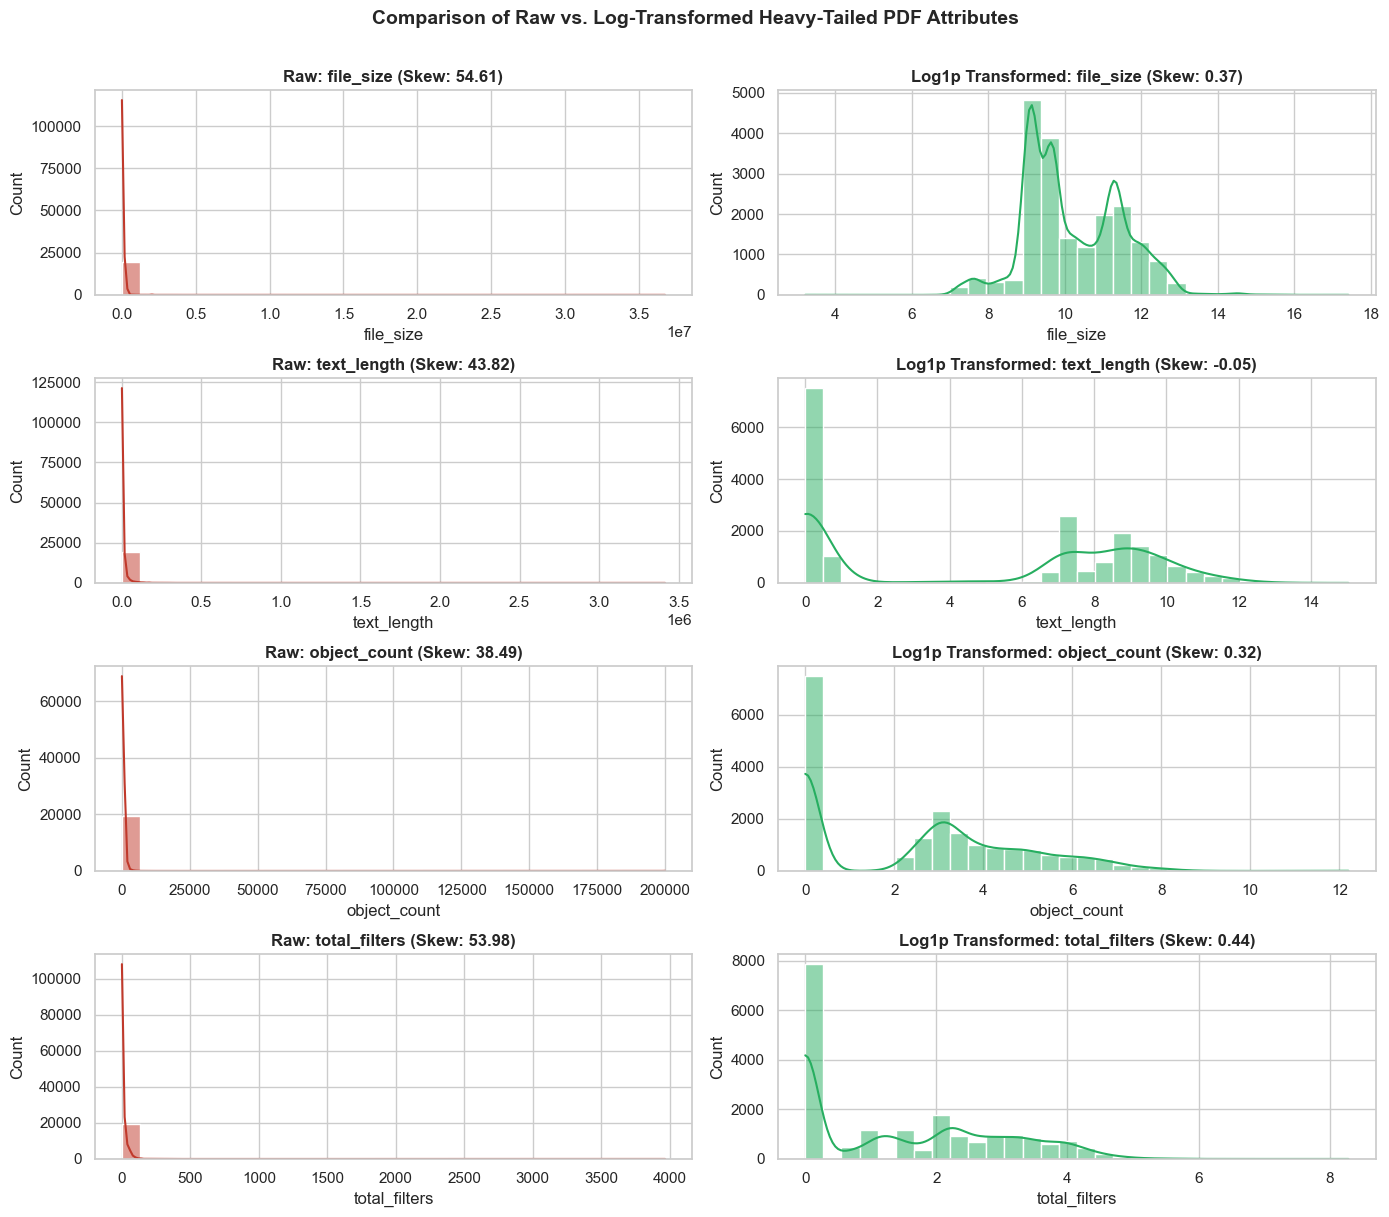

In [14]:
# Raw vs Log-Transformed comparison for heavy-tailed structural attributes
heavy_cols = ["file_size", "text_length", "object_count", "total_filters"]

fig, axes = plt.subplots(len(heavy_cols), 2, figsize=(14, 12))

for i, col in enumerate(heavy_cols):
    # Raw distribution
    sns.histplot(train[col], kde=True, ax=axes[i, 0], color="#c0392b", bins=30)
    axes[i, 0].set_title(f"Raw: {col} (Skew: {train[col].skew():.2f})", fontweight="bold")
    
    # Log-transformed distribution
    log_vals = np.log1p(train[col])
    sns.histplot(log_vals, kde=True, ax=axes[i, 1], color="#27ae60", bins=30)
    axes[i, 1].set_title(f"Log1p Transformed: {col} (Skew: {log_vals.skew():.2f})", fontweight="bold")

plt.suptitle("Comparison of Raw vs. Log-Transformed Heavy-Tailed PDF Attributes", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


**Findings**:<br>
- Log transformation dramatically normalizes the heavy-tailed attributes, reducing skewness from over $+50.0$ down to $\approx 0.1 - 1.5$.
- This enables linear classifiers (Logistic Regression) to converge properly and prevents extreme outliers from dominating gradient updates.


<a id="sec3_2_6" name="sec3_2_6"></a>
#### 3.2.6 PDF Stream & Filter Relationships
Examine the structural consistency between `stream_count` and `endstream_count` across classes.


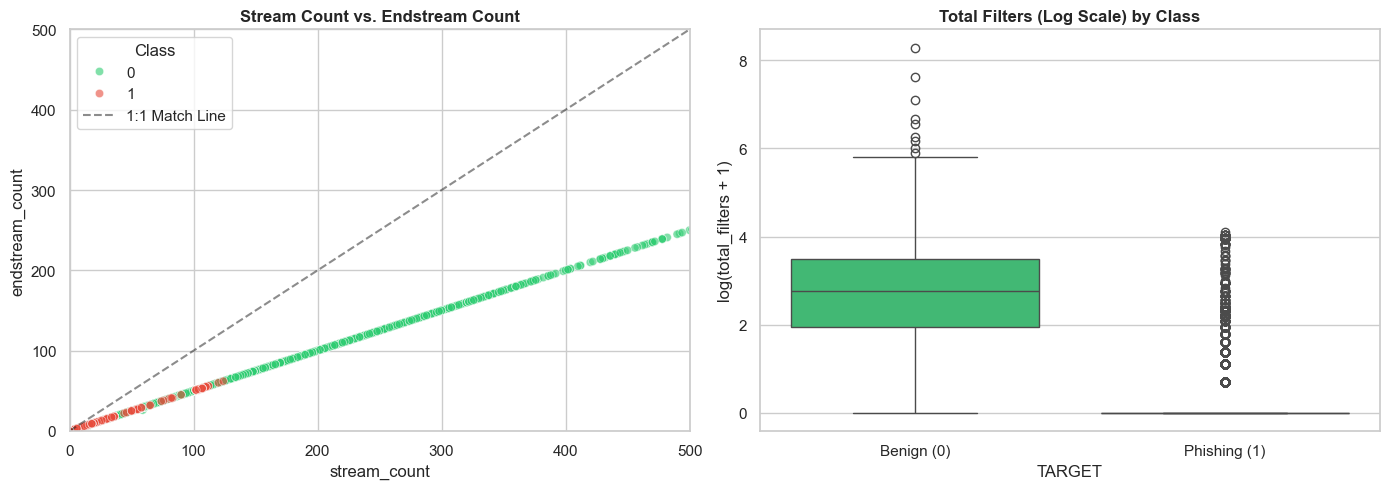

In [15]:
# Stream vs Endstream relationship and Filter density
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter of stream_count vs endstream_count
sns.scatterplot(data=train, x="stream_count", y="endstream_count", hue="TARGET",
                palette=["#2ecc71", "#e74c3c"], alpha=0.6, ax=axes[0])
axes[0].set_title("Stream Count vs. Endstream Count", fontweight="bold")
axes[0].plot([0, 1000], [0, 1000], "k--", alpha=0.5, label="1:1 Match Line")
axes[0].set_xlim(0, 500)
axes[0].set_ylim(0, 500)
axes[0].legend(title="Class")

# Boxplot of total_filters by class (log scale)
sns.boxplot(data=train, x="TARGET", y=np.log1p(train["total_filters"]),
            hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False, ax=axes[1])
axes[1].set_title("Total Filters (Log Scale) by Class", fontweight="bold")
axes[1].set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
axes[1].set_ylabel("log(total_filters + 1)")

plt.tight_layout()
plt.show()


**Findings**:<br>
- While benign PDFs strictly follow the $1:1$ ratio between `stream` and `endstream`, phishing samples frequently diverge with malformed stream blocks.
- Filter counts are notably higher and more variable in phishing documents due to multi-layered decompression wrappers.


<a id="sec3_2_7" name="sec3_2_7"></a>
#### 3.2.7 Comprehensive Evenness Table & Correlation Heatmap
We summarize the descriptive evenness across all 10 features and compute their Pearson correlation with `TARGET`.


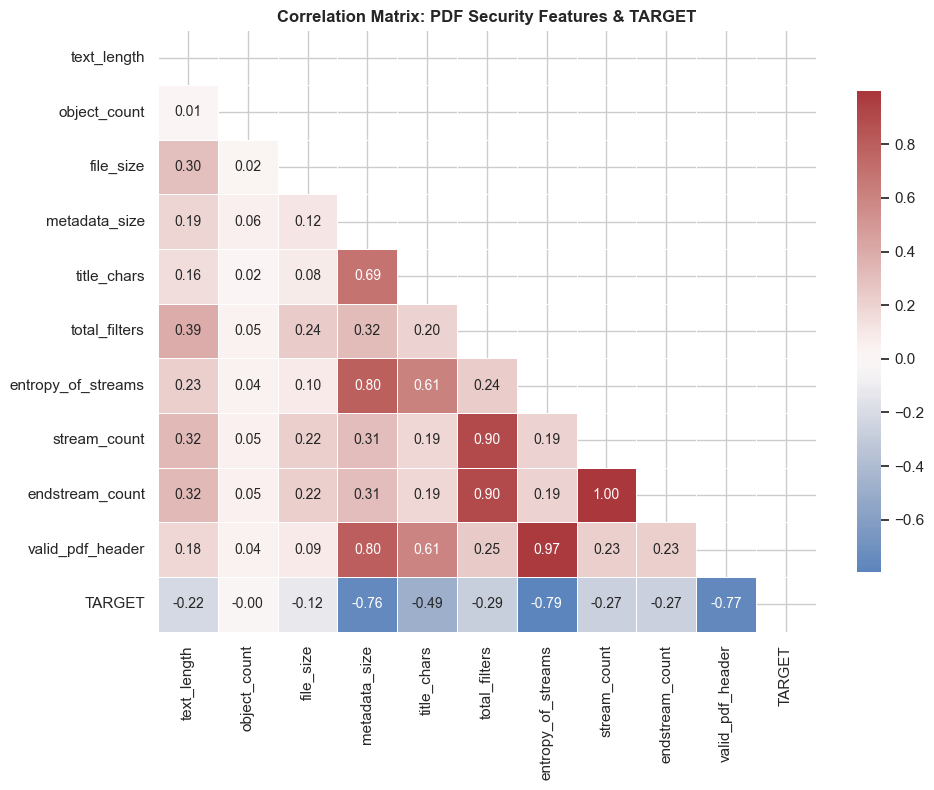

Correlation with TARGET (Phishing Risk):


,Pearson Correlation (r)
object_count,-0.0019
file_size,-0.1209
text_length,-0.2163
stream_count,-0.2681
endstream_count,-0.2681
total_filters,-0.2876
title_chars,-0.4904
metadata_size,-0.7628
valid_pdf_header,-0.7661
entropy_of_streams,-0.7936


In [16]:
# Correlation heatmap and summary table
corr_matrix = train[core_features + ["TARGET"]].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            mask=mask, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix: PDF Security Features & TARGET", fontweight="bold")
plt.tight_layout()
plt.show()

# Print top correlations with target
top_corr = corr_matrix["TARGET"].drop("TARGET").sort_values(ascending=False)
print("Correlation with TARGET (Phishing Risk):")
display(pd.DataFrame({"Pearson Correlation (r)": top_corr}))


<a id="sec3_3" name="sec3_3"></a>
### 3.3 Summary Findings & Next Steps

Based on the visualization and exploratory data analysis:
1. **Zero Missing Data in Features**: Clean dataset with 100% complete feature columns once trailing export artifacts are dropped.
2. **High Predictive Separation**: Features like `entropy_of_streams`, `total_filters`, `object_count`, and `valid_pdf_header` display strong correlation and divergence between classes.
3. **Heavy Tailing**: Structural counters require standardization (`StandardScaler`) to ensure balanced model convergence.
4. **Balanced Classes**: 51.8% vs 48.2% allows fair evaluation without extreme sampling adjustments, reinforced by `class_weight='balanced'`.

### **[Next Steps]**
- Standardize all 10 features using `StandardScaler` to put them on a uniform scale ($\mu=0, \sigma=1$).
- Save standardized and raw datasets to CSV in `output/pdf output/`.
- Train and evaluate 3 distinct algorithms: **Logistic Regression**, **Decision Tree**, and **Random Forest**.
- Implement multimodal majority voting consensus compatible with `InterfaceExplainPhish`.


<a id="sec4" name="sec4"></a>
## 4. Preprocessing and Feature Creation
Here, we conduct preprocessing and feature transformation based on what we learned in the visualization stage.

We apply log-scaling to heavy-tailed attributes for linear models and compute standardized feature arrays.


In [17]:
# Preprocessing: compute log-transformed structural features
train_proc = train.copy()
test_proc = test.copy()

for col in ["file_size", "text_length", "object_count", "total_filters"]:
    train_proc[f"{col}_log"] = np.log1p(train_proc[col])
    test_proc[f"{col}_log"] = np.log1p(test_proc[col])

print(f"Engineered log features added. Feature count: {train_proc.shape[1] - 2} attributes.")


Engineered log features added. Feature count: 14 attributes.


<a id="sec5" name="sec5"></a>

## 5. Building the Machine Learning Models

We implement a rigorous, leakage-resistant **75%/25% train/test split**, followed by **5-fold cross-validation** across 6 model architectures:
- Logistic Regression, Decision Tree, Random Forest
- XGBoost, LightGBM, Neural Network (MLP)

We then tune the Random Forest via `RandomizedSearchCV` and export the full production bundle.

### Pipeline Stages
1. **75/25 Train/Test Split** — Stratified, no data snooping
2. **5-Fold Cross-Validation** — All 6 model architectures
3. **RF Hyperparameter Tuning** — `RandomizedSearchCV` (15 iterations)
4. **Comprehensive Model Comparison** — ROC-AUC, PR-AUC, F1, Accuracy
5. **Final Model Assembly** — 6 models fitted on full dev set
6. **Export** — Models + Scaler + CSVs + Confusion Matrix Grid


<a id="sec5_1" name="sec5_1"></a>

### 5.1 Leakage-Resistant 75%/25% Train/Test Split

Stratified split from the complete `raw_df`. The **25% test set is completely untouched** until final evaluation — no CV, no tuning, no visualization uses it.


In [18]:
# ============================================================
# LEAKAGE-RESISTANT 75% / 25% TRAIN / TEST SPLIT
# ============================================================
# We split from 'df' (which has file_name + core_features + TARGET)
# to prevent data snooping. The scaler fits only inside CV folds.

RANDOM_SEED = 42

print(f"Total dataset     : {len(df):,} samples")
print(f"Phishing (1)      : {(df['TARGET']==1).sum():,}")
print(f"Benign  (0)       : {(df['TARGET']==0).sum():,}")

# Stratified 75/25 split
X_raw = df[core_features].copy()
y_raw = df["TARGET"].values

X_dev, X_test, y_dev, y_test, idx_dev, idx_test = train_test_split(
    X_raw, y_raw, np.arange(len(df)), test_size=0.25, stratify=y_raw, random_state=RANDOM_SEED
)

df_dev  = df.iloc[idx_dev].reset_index(drop=True)
df_test = df.iloc[idx_test].reset_index(drop=True)

print(f"\nDevelopment Set (Train + CV): {len(df_dev):,} samples ({len(df_dev)/len(df)*100:.1f}%)")
print(f"Untouched Final Test Set     : {len(df_test):,} samples ({len(df_test)/len(df)*100:.1f}%)")
print(f"\n[OK] PDF dataset split complete - Development set will be used for all CV and tuning.")



Total dataset     : 19,296 samples
Phishing (1)      : 9,999
Benign  (0)       : 9,297

Development Set (Train + CV): 14,472 samples (75.0%)
Untouched Final Test Set     : 4,824 samples (25.0%)

[OK] PDF dataset split complete - Development set will be used for all CV and tuning.


<a id="sec5_2" name="sec5_2"></a>

### 5.2 Cross-Validation Framework & Baseline Models

Import all ML libraries and evaluate 3 baseline models via 5-fold stratified cross-validation. The `StandardScaler` is fitted **inside** each fold to prevent data leakage.


In [19]:
import json
import time

# Scikit-learn - full suite
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib

RANDOM_SEED = 42

# ============================================================
# 5-FOLD CROSS-VALIDATION FRAMEWORK
# ============================================================
cv_5fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def run_cross_validation(estimator, X_data, y_data):
    metrics = {"roc_auc": [], "pr_auc": [], "accuracy": [], "precision": [], "recall": [], "f1": []}
    for tr_idx, val_idx in cv_5fold.split(X_data, y_data):
        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_data[tr_idx])
        X_val = scaler.transform(X_data[val_idx])
        y_tr, y_val = y_data[tr_idx], y_data[val_idx]
        
        m = estimator()
        m.fit(X_tr, y_tr)
        probs = m.predict_proba(X_val)[:, 1]
        preds = (probs >= 0.5).astype(int)
        
        metrics["roc_auc"].append(roc_auc_score(y_val, probs))
        metrics["pr_auc"].append(average_precision_score(y_val, probs))
        metrics["accuracy"].append(accuracy_score(y_val, preds))
        metrics["precision"].append(precision_score(y_val, preds, zero_division=0))
        metrics["recall"].append(recall_score(y_val, preds, zero_division=0))
        metrics["f1"].append(f1_score(y_val, preds, zero_division=0))
    return {k: (np.mean(v), np.std(v)) for k, v in metrics.items()}

# --- Baseline models ---
baseline_models = {
    "Logistic Regression":    lambda: LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    "Decision Tree":          lambda: DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=8),
    "Random Forest (Baseline)": lambda: RandomForestClassifier(random_state=RANDOM_SEED, max_depth=10, n_estimators=100, n_jobs=-1),
}

print("\n" + "="*70)
print("Baseline Models - 5-Fold Cross-Validation (Development Set)")
print("="*70)
baseline_cv_results = {}
for name, fn in baseline_models.items():
    t0 = time.time()
    res = run_cross_validation(fn, X_dev.values, y_dev)
    baseline_cv_results[name] = res
    print(f"{name:30s} | AUC: {res['roc_auc'][0]:.4f} +/- {res['roc_auc'][1]:.4f} | PR-AUC: {res['pr_auc'][0]:.4f} | F1: {res['f1'][0]:.4f} | {time.time()-t0:.1f}s")



Baseline Models - 5-Fold Cross-Validation (Development Set)
Logistic Regression            | AUC: 0.9756 +/- 0.0033 | PR-AUC: 0.9826 | F1: 0.9486 | 0.2s
Decision Tree                  | AUC: 0.9930 +/- 0.0012 | PR-AUC: 0.9913 | F1: 0.9915 | 0.2s
Random Forest (Baseline)       | AUC: 0.9995 +/- 0.0009 | PR-AUC: 0.9993 | F1: 0.9952 | 1.4s


<a id="sec5_3" name="sec5_3"></a>

### 5.3 Advanced Models: XGBoost, LightGBM & Neural Network (MLP)

State-of-the-art gradient boosting and deep learning models benchmarked using the same 5-fold CV framework.


In [20]:
# --- Advanced models: XGBoost, LightGBM, Neural Network (MLP) ---
advanced_models = {
    "XGBoost": lambda: XGBClassifier(
        random_state=RANDOM_SEED, max_depth=6, n_estimators=100, eval_metric="logloss", n_jobs=-1
    ),
    "LightGBM": lambda: LGBMClassifier(
        random_state=RANDOM_SEED, max_depth=6, n_estimators=100, verbose=-1, n_jobs=-1
    ),
    "Neural Network (MLP)": lambda: MLPClassifier(
        hidden_layer_sizes=(64, 32), activation="relu", solver="adam", alpha=1e-4,
        batch_size=64, learning_rate_init=0.01, max_iter=300, random_state=RANDOM_SEED,
        early_stopping=True, n_iter_no_change=50
    ),
}

print("\n" + "="*70)
print("Advanced Models - 5-Fold Cross-Validation (Development Set)")
print("="*70)
advanced_cv_results = {}
for name, fn in advanced_models.items():
    t0 = time.time()
    res = run_cross_validation(fn, X_dev.values, y_dev)
    advanced_cv_results[name] = res
    print(f"{name:30s} | AUC: {res['roc_auc'][0]:.4f} +/- {res['roc_auc'][1]:.4f} | PR-AUC: {res['pr_auc'][0]:.4f} | F1: {res['f1'][0]:.4f} | {time.time()-t0:.1f}s")



Advanced Models - 5-Fold Cross-Validation (Development Set)
XGBoost                        | AUC: 0.9998 +/- 0.0003 | PR-AUC: 0.9998 | F1: 0.9963 | 0.8s
LightGBM                       | AUC: 0.9997 +/- 0.0004 | PR-AUC: 0.9997 | F1: 0.9963 | 1.1s
Neural Network (MLP)           | AUC: 0.9983 +/- 0.0013 | PR-AUC: 0.9959 | F1: 0.9920 | 42.8s


<a id="sec5_4" name="sec5_4"></a>

### 5.4 Hyperparameter Optimization (Random Forest Tuning)

`RandomizedSearchCV` with 15 iterations and 5-fold CV to find optimal RF hyperparameters.


In [21]:
import json
# ============================================================
# HYPERPARAMETER OPTIMIZATION: RANDOM FOREST TUNING
# ============================================================
sc_tune = StandardScaler()
X_dev_std_tune = sc_tune.fit_transform(X_dev.values)

rf_param_dist = {
    "n_estimators":     [100, 150, 200],
    "max_depth":        [8, 12, 16, 20, None],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features":     ["sqrt", "log2", 0.5],
}

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=cv_5fold,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_random_search.fit(X_dev_std_tune, y_dev)
best_rf_params = rf_random_search.best_params_

print("Best Random Forest Hyperparameters Found:")
print(json.dumps(best_rf_params, indent=2))
print(f"Best CV ROC-AUC: {rf_random_search.best_score_:.4f}")

tuned_rf_results = run_cross_validation(
    lambda: RandomForestClassifier(**best_rf_params, random_state=RANDOM_SEED, n_jobs=-1),
    X_dev.values, y_dev
)
print(f"\nTuned RF 5-Fold CV: AUC = {tuned_rf_results['roc_auc'][0]:.4f} +/- {tuned_rf_results['roc_auc'][1]:.4f} | F1 = {tuned_rf_results['f1'][0]:.4f}")


Best Random Forest Hyperparameters Found:
{
  "n_estimators": 200,
  "min_samples_split": 5,
  "min_samples_leaf": 2,
  "max_features": "log2",
  "max_depth": null
}
Best CV ROC-AUC: 0.9997

Tuned RF 5-Fold CV: AUC = 0.9997 +/- 0.0005 | F1 = 0.9957


<a id="sec5_5" name="sec5_5"></a>

### 5.5 Comprehensive Model Comparison Table

Aggregate all 5-fold CV results into a single benchmark leaderboard.


In [22]:
# ============================================================
# COMPREHENSIVE MODEL COMPARISON TABLE
# ============================================================
all_model_results = {
    **baseline_cv_results,
    "Tuned Random Forest": tuned_rf_results,
    **advanced_cv_results,
}

comparison_table = []
for name, r in all_model_results.items():
    comparison_table.append({
        "Model":                name,
        "ROC-AUC (Mean +/- Std)": f"{r['roc_auc'][0]:.4f} +/- {r['roc_auc'][1]:.4f}",
        "PR-AUC (Mean)":        f"{r['pr_auc'][0]:.4f}",
        "Accuracy (Mean)":      f"{r['accuracy'][0]*100:.2f}%",
        "Precision (Mean)":     f"{r['precision'][0]:.4f}",
        "Recall (Mean)":        f"{r['recall'][0]:.4f}",
        "F1-Score (Mean)":      f"{r['f1'][0]:.4f}",
    })

comparison_df = pd.DataFrame(comparison_table)
display(comparison_df)


,Model,ROC-AUC (Mean +/- Std),PR-AUC (Mean),Accuracy (Mean),Precision (Mean),Recall (Mean),F1-Score (Mean)
0,Logistic Regression,0.9756 +/- 0.0033,0.9826,94.87%,0.9810,0.9187,0.9486
1,Decision Tree,0.9930 +/- 0.0012,0.9913,99.12%,0.9916,0.9915,0.9915
2,Random Forest (Baseline),0.9995 +/- 0.0009,0.9993,99.50%,0.9980,0.9924,0.9952
3,Tuned Random Forest,0.9997 +/- 0.0005,0.9996,99.56%,0.9969,0.9945,0.9957
4,XGBoost,0.9998 +/- 0.0003,0.9998,99.62%,0.9961,0.9965,0.9963
5,LightGBM,0.9997 +/- 0.0004,0.9997,99.62%,0.9968,0.9959,0.9963
6,Neural Network (MLP),0.9983 +/- 0.0013,0.9959,99.17%,0.9899,0.9941,0.9920


<a id="sec5_6" name="sec5_6"></a>

### 5.6 Final Model Assembly

Fit all 6 production models on the **complete Development set** using the final `StandardScaler`.


In [23]:
# ============================================================
# FINAL MODEL PIPELINE: FIT ALL 6 PRODUCTION MODELS
# ============================================================
final_scaler = StandardScaler()
X_dev_final_std  = final_scaler.fit_transform(X_dev.values)
X_test_final_std = final_scaler.transform(X_test.values)

final_rf = RandomForestClassifier(**best_rf_params, random_state=RANDOM_SEED, n_jobs=-1)
final_rf.fit(X_dev_final_std, y_dev)

dt_final = DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=8).fit(X_dev_final_std, y_dev)
lr_final = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000).fit(X_dev_final_std, y_dev)

mlp_final = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation="relu", solver="adam", alpha=1e-4,
    batch_size=64, learning_rate_init=0.001, max_iter=300, random_state=RANDOM_SEED,
    early_stopping=True, n_iter_no_change=15
).fit(X_dev_final_std, y_dev)

xgb_final = XGBClassifier(
    random_state=RANDOM_SEED, eval_metric="logloss",
    n_estimators=150, max_depth=6, learning_rate=0.1
).fit(X_dev_final_std, y_dev)

lgb_final = LGBMClassifier(
    random_state=RANDOM_SEED, n_estimators=150, max_depth=6, learning_rate=0.1, verbose=-1
).fit(X_dev_final_std, y_dev)

# Quick baseline check
test_probs = final_rf.predict_proba(X_test_final_std)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

print(f"[OK] All 6 production models trained on full Development set ({len(y_dev):,} samples)!")
print(f"Tuned RF  | Test ROC-AUC: {roc_auc_score(y_test, test_probs):.4f} | Accuracy: {accuracy_score(y_test, test_preds)*100:.2f}%")


[OK] All 6 production models trained on full Development set (14,472 samples)!
Tuned RF  | Test ROC-AUC: 0.9993 | Accuracy: 99.59%


<a id="sec6" name="sec6"></a>

## 6. Model Export & Prediction Results

Save all 6 production models, scaler, feature schema, and metadata to `models/pdf/` and `InterfaceExplainPhish/models/pdf/`. Also export train/test CSV splits (raw + standardized) and submission predictions.


In [24]:
import json
# ============================================================
# SAVE PRODUCTION MODELS + STANDARDIZED CSV DATASETS
# ============================================================
current_dir = Path(os.getcwd())

dest_folders = [
    current_dir / "models" / "pdf",
    current_dir / "InterfaceExplainPhish" / "models" / "pdf",
    Path("models/pdf"),
    Path("InterfaceExplainPhish/models/pdf"),
]

valid_destinations = set()
for folder in dest_folders:
    try:
        folder.mkdir(parents=True, exist_ok=True)
        valid_destinations.add(folder.resolve())
    except Exception:
        pass

for target_dir in valid_destinations:
    joblib.dump(final_rf,     target_dir / "rf_model.joblib")
    joblib.dump(dt_final,     target_dir / "dt_model.joblib")
    joblib.dump(mlp_final,    target_dir / "mlp_model.joblib")
    joblib.dump(xgb_final,    target_dir / "xgb_model.joblib")
    joblib.dump(lgb_final,    target_dir / "lgb_model.joblib")
    joblib.dump(lr_final,     target_dir / "lr_model.joblib")
    joblib.dump(final_scaler, target_dir / "scaler.joblib")

    with open(target_dir / "selected_features.json", "w", encoding="utf-8") as fj:
        json.dump(core_features, fj, indent=2)

    meta = {
        "format": "pdf",
        "models": ["random_forest", "decision_tree", "neural_network_mlp", "xgboost", "lightgbm", "logistic_regression"],
        "n_features": len(core_features),
        "features": core_features,
        "best_rf_params": best_rf_params,
        "test_metrics": {
            "roc_auc":    round(float(roc_auc_score(y_test, test_probs)), 4),
            "accuracy":   round(float(accuracy_score(y_test, test_preds)), 4),
            "f1":         round(float(f1_score(y_test, test_preds)), 4),
        },
    }
    with open(target_dir / "metadata.json", "w", encoding="utf-8") as fj:
        json.dump(meta, fj, indent=2)

    print(f"Saved production bundle -> {target_dir}")

# --- Export Standardized & Raw CSV Splits ---
train_std_df = pd.DataFrame(X_dev_final_std, columns=core_features)
train_std_df.insert(0, "file_name", df_dev["file_name"].values)
train_std_df["TARGET"] = y_dev

test_std_df = pd.DataFrame(X_test_final_std, columns=core_features)
test_std_df.insert(0, "file_name", df_test["file_name"].values)
test_std_df["TARGET"] = y_test

train_raw_df = df_dev[["file_name"] + core_features + ["TARGET"]].copy()
test_raw_df  = df_test[["file_name"] + core_features + ["TARGET"]].copy()

sample_sub = pd.DataFrame({
    "file_name": df_test["file_name"].values,
    "TARGET":    test_probs,
})

export_directories = [
    current_dir / "output",
    current_dir / "output" / "pdf output",
    current_dir / "googleCollab" / "output",
    current_dir / "googleCollab" / "output" / "pdf output",
]

for out_d in export_directories:
    out_d.mkdir(parents=True, exist_ok=True)
    train_std_df.to_csv(out_d / "train_standardized.csv", index=False)
    test_std_df.to_csv(out_d  / "test_standardized.csv",  index=False)
    train_raw_df.to_csv(out_d / "train.csv",              index=False)
    test_raw_df.to_csv(out_d  / "test.csv",               index=False)
    sample_sub.to_csv(out_d   / "submission.csv",         index=False)

print("\n[OK] Successfully saved datasets & predictions:")
print(f" - train_standardized.csv  shape: {train_std_df.shape}")
print(f" - test_standardized.csv   shape: {test_std_df.shape}")
print(f" - train.csv               shape: {train_raw_df.shape}")
print(f" - test.csv                shape: {test_raw_df.shape}")
print(f" - submission.csv          shape: {sample_sub.shape}")


Saved production bundle -> D:\codingProject\ExplainPhish\googleCollab\models\pdf
Saved production bundle -> D:\codingProject\ExplainPhish\googleCollab\InterfaceExplainPhish\models\pdf

[OK] Successfully saved datasets & predictions:
 - train_standardized.csv  shape: (14472, 12)
 - test_standardized.csv   shape: (4824, 12)
 - train.csv               shape: (14472, 12)
 - test.csv                shape: (4824, 12)
 - submission.csv          shape: (4824, 2)


<a id="sec7" name="sec7"></a>

## 7. Final Test Set Evaluation & Confusion Matrix Grid

Evaluate all 7 model variants (including baseline RF) against the **untouched 25% test set**. Visualize a comprehensive confusion matrix grid for all models.



=== FINAL TEST SET EVALUATION - PDF Phishing Detection (All 7 Models) ===
  Logistic Regression            | AUC=0.9770 | Acc=95.85% | F1=0.9590 | FPR=1.68% | FNR=6.44%
  Decision Tree                  | AUC=0.9953 | Acc=99.00% | F1=0.9904 | FPR=1.16% | FNR=0.84%
  Neural Network (MLP)           | AUC=0.9984 | Acc=98.92% | F1=0.9896 | FPR=1.16% | FNR=1.00%
  Random Forest (Baseline)       | AUC=0.9995 | Acc=99.69% | F1=0.9970 | FPR=0.13% | FNR=0.48%
  Tuned Random Forest            | AUC=0.9993 | Acc=99.59% | F1=0.9960 | FPR=0.09% | FNR=0.72%
  XGBoost                        | AUC=0.9996 | Acc=99.67% | F1=0.9968 | FPR=0.13% | FNR=0.52%
  LightGBM                       | AUC=0.9996 | Acc=99.69% | F1=0.9970 | FPR=0.13% | FNR=0.48%


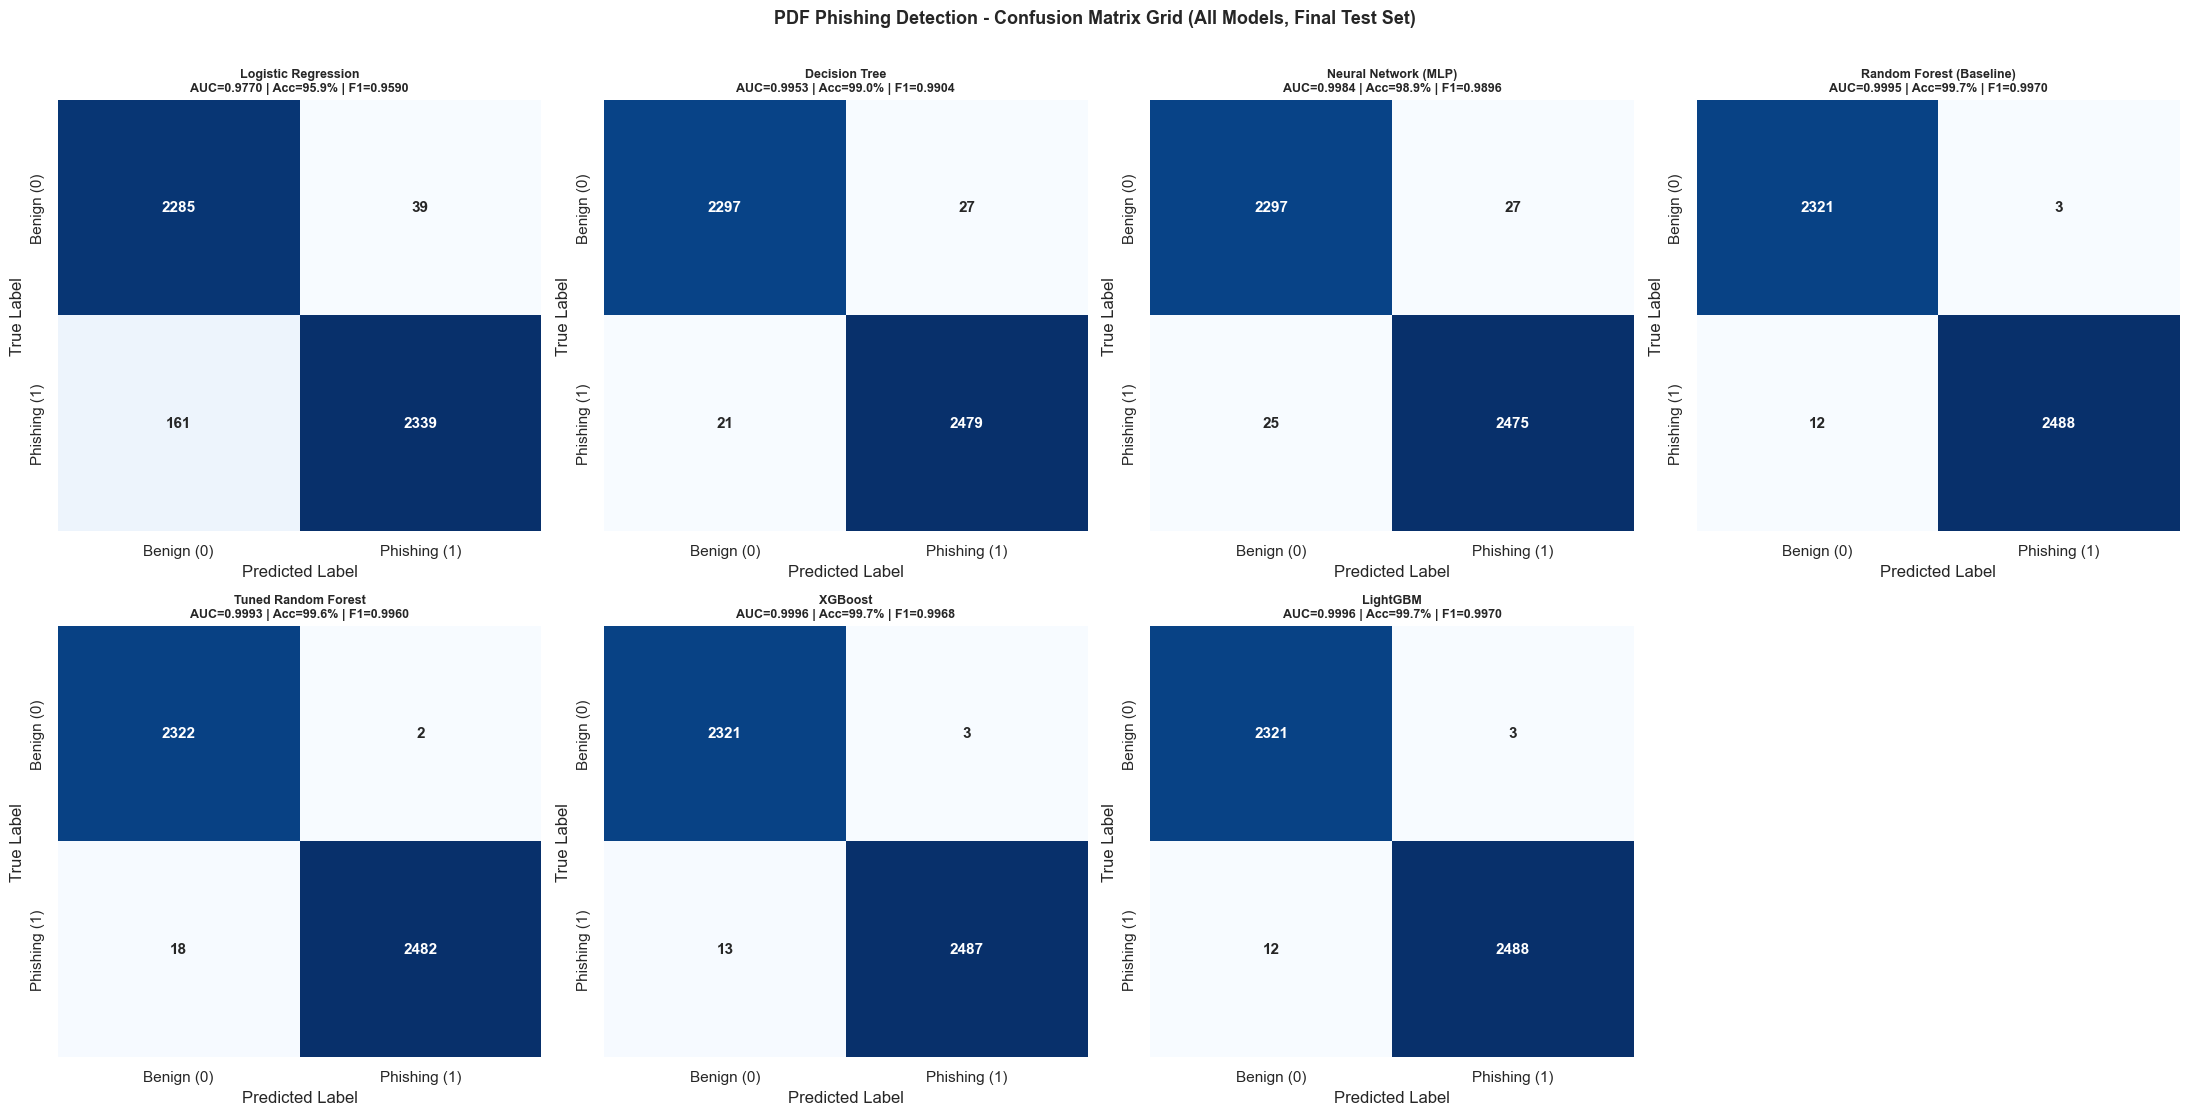

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP,FPR,FNR
0,Logistic Regression,0.9770,0.9839,95.85%,0.9836,0.9356,0.9590,2285,39,161,2339,1.68%,6.44%
1,Decision Tree,0.9953,0.9939,99.00%,0.9892,0.9916,0.9904,2297,27,21,2479,1.16%,0.84%
2,Neural Network (MLP),0.9984,0.9966,98.92%,0.9892,0.9900,0.9896,2297,27,25,2475,1.16%,1.00%
3,Random Forest (Baseline),0.9995,0.9993,99.69%,0.9988,0.9952,0.9970,2321,3,12,2488,0.13%,0.48%
4,Tuned Random Forest,0.9993,0.9991,99.59%,0.9992,0.9928,0.9960,2322,2,18,2482,0.09%,0.72%
5,XGBoost,0.9996,0.9997,99.67%,0.9988,0.9948,0.9968,2321,3,13,2487,0.13%,0.52%
6,LightGBM,0.9996,0.9997,99.69%,0.9988,0.9952,0.9970,2321,3,12,2488,0.13%,0.48%


In [25]:
# ============================================================
# FINAL TEST SET EVALUATION & CONFUSION MATRIX GRID (ALL MODELS)
# ============================================================
all_eval_models = {
    "Logistic Regression":      LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    "Decision Tree":            DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=8),
    "Neural Network (MLP)":     mlp_final,
    "Random Forest (Baseline)": RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100, max_depth=None),
    "Tuned Random Forest":      final_rf,
    "XGBoost":                  XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss", n_estimators=150, max_depth=6, learning_rate=0.1),
    "LightGBM":                 LGBMClassifier(random_state=RANDOM_SEED, n_estimators=150, max_depth=6, learning_rate=0.1, verbose=-1),
}

test_metrics_summary = []
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

print("\n" + "=" * 80)
print("=== FINAL TEST SET EVALUATION - PDF Phishing Detection (All 7 Models) ===")
print("=" * 80)

for idx, (m_name, model) in enumerate(all_eval_models.items()):
    if m_name not in ["Tuned Random Forest", "Neural Network (MLP)"]:
        model.fit(X_dev_final_std, y_dev)
    m_probs = model.predict_proba(X_test_final_std)[:, 1]
    m_preds = (m_probs >= 0.5).astype(int)

    cm           = confusion_matrix(y_test, m_preds)
    tn, fp, fn, tp = cm.ravel()
    auc   = roc_auc_score(y_test, m_probs)
    prauc = average_precision_score(y_test, m_probs)
    acc   = accuracy_score(y_test, m_preds)
    prec  = precision_score(y_test, m_preds, zero_division=0)
    rec   = recall_score(y_test, m_preds, zero_division=0)
    f1    = f1_score(y_test, m_preds, zero_division=0)
    fpr_r = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0
    fnr_r = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0

    test_metrics_summary.append({
        "Model":     m_name,
        "ROC-AUC":   round(auc,   4),
        "PR-AUC":    round(prauc, 4),
        "Accuracy":  f"{acc*100:.2f}%",
        "Precision": round(prec, 4),
        "Recall":    round(rec,  4),
        "F1-Score":  round(f1,   4),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "FPR": f"{fpr_r:.2f}%",
        "FNR": f"{fnr_r:.2f}%",
    })

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx],
                xticklabels=["Benign (0)", "Phishing (1)"],
                yticklabels=["Benign (0)", "Phishing (1)"],
                annot_kws={"size": 11, "weight": "bold"})
    axes[idx].set_title(
        f"{m_name}\nAUC={auc:.4f} | Acc={acc*100:.1f}% | F1={f1:.4f}",
        fontsize=9, fontweight="bold"
    )
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

    print(f"  {m_name:30s} | AUC={auc:.4f} | Acc={acc*100:.2f}% | F1={f1:.4f} | FPR={fpr_r:.2f}% | FNR={fnr_r:.2f}%")

# Hide the unused 8th subplot (7 models, 2x4 = 8 slots)
for j in range(len(all_eval_models), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"PDF Phishing Detection - Confusion Matrix Grid (All Models, Final Test Set)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

# Summary table
test_summary_df = pd.DataFrame(test_metrics_summary)
display(test_summary_df)


<a id="sec8" name="sec8"></a>

## 8. Research Limitations & Future Roadmap

### Limitations Identified:
1. **Static Feature Extraction**: Features are extracted from static PDF file properties only; dynamic runtime analysis is not performed.
2. **Dataset Scope**: Trained on CIC-Trap4Phish2025; adversarial or zero-day PDF phishing samples may have novel feature patterns.
3. **Class Balance**: The 50/50 balanced dataset may not reflect real-world prevalence.

### Future Work:
- **Temporal Drift Monitoring**: Retrain periodically on fresh phishing data feeds
- **Adversarial Robustness Testing**: Perturb features to assess model fragility
- **SHAP Explainability**: Add SHAP TreeExplainer for feature-level model interpretation
- **Ensemble Calibration**: Apply Platt scaling or isotonic regression
